---
title: "Practice Activity 8.1: Nonparametric Regression"
author: Lily
format:
    html:
        embed-resources: true
        code-line-numbers: true
---

**GitHub Repository**: <https://github.com/lilysteinberg/GSB-544---Computing-and-ML/tree/main/Week%207>

# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `bill_depth_mm` using the other variables in the dataset.

**Dummify** all variables that require this.

In [49]:
### packages
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from plotnine import *

In [50]:
### penguin data
!pip install palmerpenguins
from palmerpenguins import load_penguins

In [51]:
### set up penguins df
penguins = load_penguins()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [52]:
### Making dummies
penguins = pd.get_dummies(penguins, drop_first = True)
# convert bools to numbers
penguins = penguins * 1
# visual confirmation of data change
penguins.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen,sex_male
0,39.1,18.7,181.0,3750.0,2007,0,0,0,1,1
1,39.5,17.4,186.0,3800.0,2007,0,0,0,1,0
2,40.3,18.0,195.0,3250.0,2007,0,0,0,1,0
3,NaN,NaN,NaN,NaN,2007,0,0,0,1,0
4,36.7,19.3,193.0,3450.0,2007,0,0,0,1,0


In [53]:
### Drop NAs
penguins = penguins.dropna()

In [54]:
### specify x variables and y variable
X = penguins.drop(["bill_depth_mm"], axis = 1)
y = penguins["bill_depth_mm"]

Let's use the other variables to predict `bill_depth_mm`. Prepare your data and fit the following models on the entire dataset:

* Your best multiple linear regression model from before
* Two kNN models (for different values of K)
* A decision tree model

Create a plot like the right plot of Fig 1. in our `Model Validation` chapter with the training and test error plotted for each of your four models.

Which of your models was best?

In [55]:
### Linear Regression

# make pipeline
lr_pipeline = Pipeline(
    [
     ("standardize", StandardScaler()),
     ("linear_regression", LinearRegression())
    ],
).set_output(transform="pandas")

In [56]:
# save fitted linear regression
lr_pipeline_fitted = lr_pipeline.fit(X, y)
lr_pipeline_fitted

Pipeline(steps=[('standardize', StandardScaler()),
                ('linear_regression', LinearRegression())])

In [57]:
# cross-validation to estimate MSE
scores = cross_val_score(lr_pipeline,
                         X=X,
                         y=y,
                         scoring="neg_mean_squared_error",
                         cv=5)

# create list to store MSE values
MSE_compare = []

# save MSE value
MSE_compare.append({"model": "lr", "MSE": -scores.mean()})

In [58]:
### KNN

# start by tuning to see best number of neighbors
knn_pipeline = Pipeline(
    [
     ("standardize", StandardScaler()),
     ("knn", KNeighborsRegressor())
    ],
).set_output(transform="pandas")

neighbors = {'knn__n_neighbors': np.arange(1, 11, 1)}

gscv = GridSearchCV(knn_pipeline, param_grid=neighbors, cv = 5, scoring='r2')

# feed in data
gscv_fitted = gscv.fit(X, y)
gscv_fitted.cv_results_

# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.007599,0.001757,0.006303,0.002120,1,{'knn__n_neighbors': 1},-0.433805,-0.060303,0.701095,0.169626,-0.115418,0.052239,0.377308,10
1,0.008043,0.001455,0.006051,0.001306,2,{'knn__n_neighbors': 2},-0.154401,-0.018935,0.733234,0.478972,0.054951,0.218764,0.333159,9
2,0.007439,0.001838,0.005546,0.001214,3,{'knn__n_neighbors': 3},0.010068,-0.035907,0.712469,0.480063,0.306752,0.294689,0.282613,8
3,0.010506,0.000732,0.007838,0.000973,4,{'knn__n_neighbors': 4},0.065360,-0.035937,0.734019,0.425408,0.368214,0.311413,0.274230,5
4,0.010020,0.000463,0.007529,0.000247,5,{'knn__n_neighbors': 5},0.098721,-0.071660,0.723233,0.416468,0.313785,0.296110,0.272562,7
5,0.009828,0.000277,0.007484,0.000273,6,{'knn__n_neighbors': 6},0.117162,-0.105720,0.748456,0.383888,0.353675,0.299492,0.286031,6
6,0.009713,0.001427,0.007202,0.000124,7,{'knn__n_neighbors': 7},0.147853,-0.086827,0.751127,0.390490,0.356498,0.311828,0.278201,4
7,0.009068,0.000313,0.007689,0.000635,8,{'knn__n_neighbors': 8},0.151553,-0.044306,0.742606,0.419523,0.388012,0.331478,0.265917,3
8,0.005526,0.000155,0.004653,0.000291,9,{'knn__n_neighbors': 9},0.163841,0.049417,0.746400,0.412482,0.389234,0.352275,0.239815,2
9,0.005489,0.000060,0.004459,0.000126,10,{'knn__n_neighbors': 10},0.184829,0.103096,0.745537,0.405577,0.404857,0.368779,0.223171,1


In [59]:
# make pipeline for neighbors = 10
knn_best_pipeline = Pipeline(
    [
     ("standardize", StandardScaler()),
     ("knn", KNeighborsRegressor(n_neighbors = 10))
    ],
).set_output(transform="pandas")

In [60]:
# save fitted knn (neighbors = 10)
knn_pipeline_fitted = knn_best_pipeline.fit(X, y)
knn_pipeline_fitted

Pipeline(steps=[('standardize', StandardScaler()),
                ('knn', KNeighborsRegressor(n_neighbors=10))])

In [61]:
# cross-validation to estimate MSE
scores = cross_val_score(knn_best_pipeline,
                         X=X,
                         y=y,
                         scoring="neg_mean_squared_error",
                         cv=5)

# save MSE value
MSE_compare.append({"model": "knn_10", "MSE": -scores.mean()})

In [62]:
# make pipeline for neighbors = 9
knn_second_best_pipeline = Pipeline(
    [
     ("standardize", StandardScaler()),
     ("knn", KNeighborsRegressor(n_neighbors = 9))
    ],
).set_output(transform="pandas")

In [63]:
# save fitted knn (neighbors = 9)
knn_pipeline_fitted_2 = knn_second_best_pipeline.fit(X, y)
knn_pipeline_fitted_2

Pipeline(steps=[('standardize', StandardScaler()),
                ('knn', KNeighborsRegressor(n_neighbors=9))])

In [64]:
# cross-validation to estimate MSE
scores = cross_val_score(knn_second_best_pipeline,
                         X=X,
                         y=y,
                         scoring="neg_mean_squared_error",
                         cv=5)

# save MSE value
MSE_compare.append({"model": "knn_9", "MSE": -scores.mean()})

In [65]:
### Decision Tree

# start by tuning to see best number of nodes
dt_pipeline = Pipeline(
  [("dt", DecisionTreeRegressor())]
).set_output(transform="pandas")

tuning = {'dt__ccp_alpha': np.arange(0, 1, 0.1)}

gscv = GridSearchCV(dt_pipeline, param_grid=tuning, cv = 5, scoring='r2')

# feed in data
gscv_fitted = gscv.fit(X, y)
gscv_fitted.cv_results_

# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_dt__ccp_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.008685,0.001483,0.005665,0.001329,0.0,{'dt__ccp_alpha': 0.0},-0.156623,-1.120820,0.487534,0.381055,-0.365965,-0.154964,0.579227,10
1,0.007730,0.000480,0.004475,0.000153,0.1,{'dt__ccp_alpha': 0.1},0.268056,0.387136,0.650848,0.349870,0.530226,0.437227,0.136413,1
2,0.007726,0.000245,0.004215,0.000270,0.2,{'dt__ccp_alpha': 0.2},0.268056,0.387136,0.439255,-0.243617,0.530226,0.276211,0.273386,2
3,0.008182,0.001103,0.004682,0.000558,0.3,{'dt__ccp_alpha': 0.30000000000000004},0.268056,0.387136,0.439255,-0.243617,-0.004338,0.169298,0.257189,3
4,0.007350,0.000252,0.004305,0.000149,0.4,{'dt__ccp_alpha': 0.4},-0.060017,-0.020073,0.439255,-0.243617,-0.004338,0.022242,0.225319,9
5,0.007984,0.000638,0.004895,0.000888,0.5,{'dt__ccp_alpha': 0.5},-0.060017,-0.020073,0.443933,-0.243617,-0.004338,0.023177,0.227052,4
6,0.006876,0.001447,0.004260,0.001210,0.6,{'dt__ccp_alpha': 0.6000000000000001},-0.060017,-0.020073,0.443933,-0.243617,-0.004338,0.023177,0.227052,8
7,0.006161,0.001104,0.003832,0.000938,0.7,{'dt__ccp_alpha': 0.7000000000000001},-0.060017,-0.020073,0.443933,-0.243617,-0.004338,0.023177,0.227052,5
8,0.008012,0.000899,0.004833,0.001138,0.8,{'dt__ccp_alpha': 0.8},-0.060017,-0.020073,0.443933,-0.243617,-0.004338,0.023177,0.227052,6
9,0.008057,0.001168,0.004289,0.000453,0.9,{'dt__ccp_alpha': 0.9},-0.060017,-0.020073,0.443933,-0.243617,-0.004338,0.023177,0.227052,7


In [66]:
# make pipeline for ccp_alpha = 0.1
dt_best_pipeline = Pipeline(
  [
  ("dt", DecisionTreeRegressor(ccp_alpha=0.1))]
).set_output(transform="pandas")

In [67]:
# save fitted df (ccp_alpha = 0.1)
dt_pipeline_fitted = dt_best_pipeline.fit(X, y)
dt_pipeline_fitted

Pipeline(steps=[('dt', DecisionTreeRegressor(ccp_alpha=0.1))])

In [68]:
# cross-validation to estimate MSE
scores = cross_val_score(dt_best_pipeline,
                         X=X,
                         y=y,
                         scoring="neg_mean_squared_error",
                         cv=5)

# save MSE value
MSE_compare.append({"model": "dt", "MSE": -scores.mean()})

In [69]:
### Compare MSEs

# display saved MSE values in dataframe
MSE_compare_df = pd.DataFrame(MSE_compare)
MSE_compare_df.sort_values(by = "MSE", ascending = True)

,model,MSE
3,dt,0.777497
1,knn_10,0.861039
2,knn_9,0.884458
0,lr,0.918146


As shown above, the decision tree had the lowest MSE value, therefore performing the best. These values came from cross validation methods.

Next, I'll use train/test split as part of making a graph.

In [70]:
# data partitioning
X_train, X_test, y_train, y_test = train_test_split(penguins.drop(['bill_depth_mm'], axis=1), penguins[['bill_depth_mm']], test_size=0.25)

# fit parititioned data to models
lr_pipeline_fitted_plot = lr_pipeline.fit(X=X_train, y=y_train)
knn_pipeline_fitted_plot_10 = knn_best_pipeline.fit(X=X_train, y=y_train)
knn_pipeline_fitted_plot_9 = knn_second_best_pipeline.fit(X=X_train, y=y_train)
dt_pipeline_fitted_plot = dt_best_pipeline.fit(X=X_train, y=y_train)

In [71]:
# create lists to store MSE values
MSE_compare_plot_train = []
MSE_compare_plot_test = []

### lr - train data
# make predictions
y_train_ = lr_pipeline_fitted_plot.predict(X_train)
# calculate MSE
train_mse = mean_squared_error(y_train, y_train_)
# save MSE value
MSE_compare_plot_train.append({"model": "lr", "train MSE": train_mse})

### lr - test data
# make predictions
y_test_ = lr_pipeline_fitted_plot.predict(X_test)
# calculate MSE
test_mse = mean_squared_error(y_test, y_test_)
# save MSE value
MSE_compare_plot_test.append({"model": "lr", "test MSE": test_mse})

In [72]:
### KNN, neighbots = 10 - train data
# make predictions
y_train_ = knn_pipeline_fitted_plot_10.predict(X_train)
# calculate MSE
train_mse = mean_squared_error(y_train, y_train_)
# save MSE value
MSE_compare_plot_train.append({"model": "knn-10", "train MSE": train_mse})

### KNN, neighbots = 10 - test data
# make predictions
y_test_ = knn_pipeline_fitted_plot_10.predict(X_test)
# calculate MSE
test_mse = mean_squared_error(y_test, y_test_)
# save MSE value
MSE_compare_plot_test.append({"model": "knn-10", "test MSE": test_mse})

In [73]:
### KNN, neighbots = 9 - train data
# make predictions
y_train_ = knn_pipeline_fitted_plot_9.predict(X_train)
# calculate MSE
train_mse = mean_squared_error(y_train, y_train_)
# save MSE value
MSE_compare_plot_train.append({"model": "knn-9", "train MSE": train_mse})

### KNN, neighbots = 9 - test data
# make predictions
y_test_ = knn_pipeline_fitted_plot_9.predict(X_test)
# calculate MSE
test_mse = mean_squared_error(y_test, y_test_)
# save MSE value
MSE_compare_plot_test.append({"model": "knn-9", "test MSE": test_mse})

In [74]:
### decision tree - train data
# make predictions
y_train_ = dt_pipeline_fitted_plot.predict(X_train)
# calculate MSE
train_mse = mean_squared_error(y_train, y_train_)
# save MSE value
MSE_compare_plot_train.append({"model": "dt", "train MSE": train_mse})

### decision tree - test data
# make predictions
y_test_ = dt_pipeline_fitted_plot.predict(X_test)
# calculate MSE
test_mse = mean_squared_error(y_test, y_test_)
# save MSE value
MSE_compare_plot_test.append({"model": "dt", "test MSE": test_mse})

In [75]:
### Cleaning data for plot
MSE_compare_plot_train = pd.DataFrame(MSE_compare_plot_train)
MSE_compare_plot_test = pd.DataFrame(MSE_compare_plot_test)
# merge error dfs into one df
df_error = MSE_compare_plot_train.merge(MSE_compare_plot_test, on="model")
# convert to long format for graphing
df_error_long = df_error.melt(id_vars= ["model"], value_vars = ["train MSE", "test MSE"], var_name = "type", value_name = "MSE")

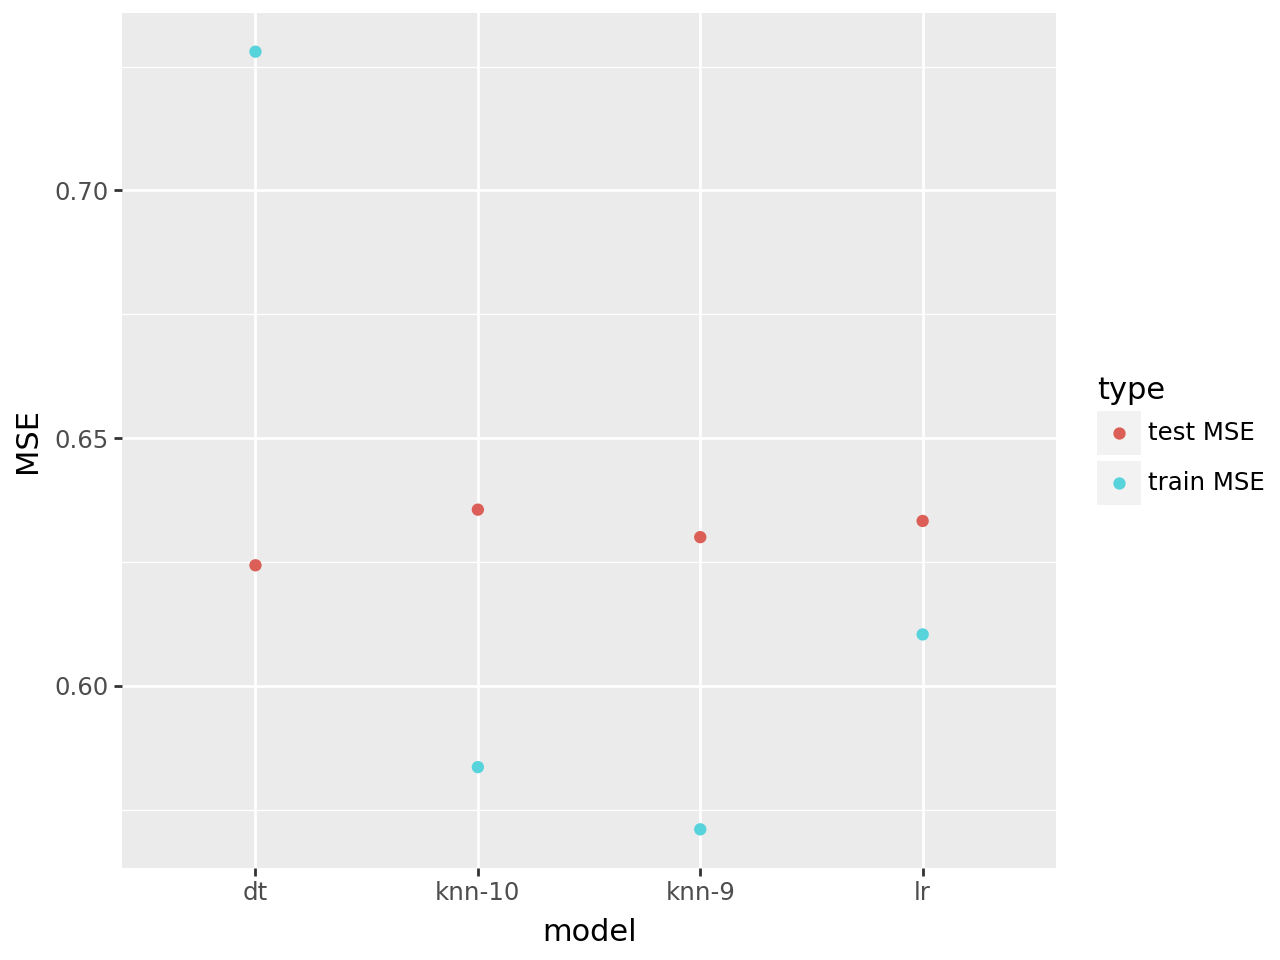

In [76]:
# graph
(ggplot(df_error_long,
        aes(x = "model",
            y = "MSE",
            color = "type"))
+ geom_point())

According to the train/test split method, the decision tree model still performed the best, as seen with the lowest MSE value for the test data. However, these MSE numbers depend on how the data is partitioned, which occurs randomly. These numbers may change slightly if the code is run again, possibly even to change the outcome.